In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qclab import Simulation # import simulation class 
from qclab.models import SpinBoson, AdiabaticSpinBoson # import model class 
from qclab.algorithms import MeanField, AdiabaticMeanField # import algorithm class 
from qclab.dynamics import serial_driver # import dynamics driver

In [ ]:
sim = Simulation()

sim.settings.num_trajs = 1
sim.settings.batch_size = 50
sim.settings.tmax = 30
sim.settings.dt_update = 0.01

sim.model = SpinBoson({
    'V':0.5,
    'E':0.5,
    'A':10,
    'W':0.1,
    'l_reorg':0.05,
    'boson_mass':1.0,
    'kBT':1.0,
})
sim.algorithm = MeanField()

def calc_adb_pops(sim, state, parameters):
    h = state["h_q_tot"]
    evals, evecs = np.linalg.eigh(h)
    wf_adb = np.einsum('tia,ti->ta', evecs.conj(), state["wf_db"])
    state["output_dict"]["adb_pops"] = np.abs(wf_adb)**2
    return state, parameters

sim.algorithm.collect_recipe.append(calc_adb_pops)

sim.initial_state["wf_db"]= np.array([1,1], dtype=complex)/np.sqrt(2)

data = serial_driver(sim)

t = data.data_dict['t']
pops_adb = np.real(data.data_dict['adb_pops'])
plt.plot(t, pops_adb)
plt.title('Adiabatic populations')
plt.show()

In [ ]:

t = data.data_dict['t']
ec = data.data_dict['classical_energy']
eq = data.data_dict['quantum_energy']
etot = ec + eq
plt.plot(t, ec-ec[0], label='Classical Energy')
plt.plot(t, eq-eq[0], label='Quantum Energy')
plt.plot(t, etot-etot[0], label='Total Energy', linestyle='--')
plt.legend()
plt.title('Energies')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qclab import Simulation # import simulation class 
from qclab.models import SpinBoson, AdiabaticSpinBoson # import model class 
from qclab.algorithms import MeanField, AdiabaticMeanField, AbInitioMeanField # import algorithm class 
from qclab.dynamics import serial_driver # import dynamics driver


sim = Simulation()

sim.settings.num_trajs = 1
sim.settings.batch_size = 50
sim.settings.tmax = 30
sim.settings.dt_update = 0.0001
sim.settings.dt_collect = sim.settings.dt_update

sim.model = AdiabaticSpinBoson({
    'V':0.5,
    'E':0.5,
    'A':100,
    'W':0.1,
    'l_reorg':0.005,
    'boson_mass':1.0,
    'kBT':1.0,
})
sim.algorithm = AdiabaticMeanField({"update_wf_adb_eig_num_substeps":1})#


sim.initial_state["wf_adb"]= np.array([1,1], dtype=complex)/np.sqrt(2)

data = serial_driver(sim)

# t = data.data_dict['t']
# pops_adb = np.real(np.einsum('ti->ti', data.data_dict['adb_pops']))
# plt.plot(t, pops_adb)
# plt.title('Adiabatic populations')
# plt.show()

In [3]:
import numpy as np
A = np.array([{} for a in range(10)])
print(A)
print(A.dtype)

[{} {} {} {} {} {} {} {} {} {}]
object


In [ ]:
print(etot-etot[0])

In [ ]:

t = data.data_dict['t']
ec = data.data_dict['classical_energy']
eq = data.data_dict['quantum_energy']
etot = ec + eq
plt.plot(t, ec-0*ec[0], label='Classical Energy')
plt.plot(t, eq-0*eq[0], label='Quantum Energy')
plt.plot(t, etot-0*etot[0], label='Total Energy', linestyle='--')
plt.legend()
plt.title('Energies')
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qclab import Simulation, functions # import simulation class 
from qclab.models import SpinBoson, AdiabaticSpinBoson # import model class 
from qclab.algorithms import MeanField, AbInitioMeanField, AbInitioFewestSwitchesSurfaceHopping # import algorithm class 
from qclab.dynamics import serial_driver # import dynamics driver


sim = Simulation()

sim.settings.num_trajs = 1
sim.settings.batch_size = 1
sim.settings.tmax = 15
sim.settings.dt_update = 0.01
sim.settings.dt_collect = sim.settings.dt_update

sim.model = AdiabaticSpinBoson({
    'V':0.5,
    'E':0.5,
    'A':10,
    'W':0.1,
    'l_reorg':0.5,
    'boson_mass':1.0,
    'kBT':1.0,
})

def collect_qp(sim, state, parameters):
    m = sim.model.constants.classical_coordinate_mass
    h = sim.model.constants.classical_coordinate_weight
    p = functions.z_to_p(state["z"], m[np.newaxis], h[np.newaxis])
    q = functions.z_to_q(state["z"], m[np.newaxis], h[np.newaxis])
    state["output_dict"]["q"] = q
    state["output_dict"]["p"] = p
    state["output_dict"]["energy"] = np.einsum('tii->ti',state["h_q_tot"])
    state["output_dict"]["wf_adb"] = state["wf_adb"]
    return state, parameters

# sim.algorithm = AbInitioMeanField({"update_wf_adb_eig_num_substeps":10})#AdiabaticMeanField({"update_wf_adb_eig_num_substeps":1})#
sim.algorithm = AbInitioFewestSwitchesSurfaceHopping({"update_wf_adb_eig_num_substeps":100})
sim.algorithm.collect_recipe.append(collect_qp)

sim.initial_state["wf_adb"]= np.array([1,1], dtype=complex)/np.sqrt(2)

data = serial_driver(sim)

# t = data.data_dict['t']
# pops_adb = np.real(np.einsum('ti->ti', data.data_dict['adb_pops']))
# plt.plot(t, pops_adb)
# plt.title('Adiabatic populations')
# plt.show()

  0%|          | 0/1501 [00:00<?, ?it/s]

adiabatic connection
[[[ 0.       +0.j  0.0058099+0.j]
  [-0.0058099+0.j  0.       +0.j]]]
adiabatic connection
[[[ 0.        +0.j  0.00581759+0.j]
  [-0.00581759+0.j  0.        +0.j]]]


  3%|▎         | 39/1501 [00:01<00:34, 42.49it/s]

[0.00296252 0.00104815]
adiabatic connection
[[[ 0.        +0.j  0.00591313+0.j]
  [-0.00591313+0.j  0.        +0.j]]]
[1.88849558e-03 6.46560964e-05]
adiabatic connection
[[[ 0.        +0.j  0.00604078+0.j]
  [-0.00604078+0.j  0.        +0.j]]]
[1.92547860e-03 6.59024777e-05]
adiabatic connection
[[[ 0.        +0.j  0.00616726+0.j]
  [-0.00616726+0.j  0.        +0.j]]]
[1.96191556e-03 6.71417787e-05]
adiabatic connection
[[[ 0.        +0.j  0.00629256+0.j]
  [-0.00629256+0.j  0.        +0.j]]]
[1.99780160e-03 6.83731922e-05]
adiabatic connection
[[[ 0.        +0.j  0.00641666+0.j]
  [-0.00641666+0.j  0.        +0.j]]]
[2.03313193e-03 6.95959156e-05]
adiabatic connection
[[[ 0.        +0.j  0.00653954+0.j]
  [-0.00653954+0.j  0.        +0.j]]]
[2.06790185e-03 7.08091520e-05]
adiabatic connection
[[[ 0.        +0.j  0.00666119+0.j]
  [-0.00666119+0.j  0.        +0.j]]]
[2.10210676e-03 7.20121105e-05]
adiabatic connection
[[[ 0.        +0.j  0.00678158+0.j]
  [-0.00678158+0.j  0.        

  5%|▌         | 77/1501 [00:01<00:16, 87.60it/s]

...

adiabatic connection
[[[ 0.        +0.j -0.01173697+0.j]
  [ 0.01173697+0.j  0.        +0.j]]]
[2.89002838e-03 7.66034050e-05]
adiabatic connection
[[[ 0.        +0.j -0.01155546+0.j]
  [ 0.01155546+0.j  0.        +0.j]]]
[2.85049684e-03 7.52118983e-05]
adiabatic connection
[[[ 0.        +0.j -0.01137264+0.j]
  [ 0.01137264+0.j  0.        +0.j]]]
[2.81036623e-03 7.38132817e-05]
adiabatic connection
[[[ 0.        +0.j -0.01118854+0.j]
  [ 0.01118854+0.j  0.        +0.j]]]
[2.76964358e-03 7.24084658e-05]
adiabatic connection
[[[ 0.        +0.j -0.01100319+0.j]
  [ 0.01100319+0.j  0.        +0.j]]]
[2.72833602e-03 7.09983657e-05]
adiabatic connection
[[[ 0.        +0.j -0.01081661+0.j]
  [ 0.01081661+0.j  0.        +0.j]]]
[2.68645080e-03 6.95838996e-05]
adiabatic connection
[[[ 0.        +0.j -0.01062882+0.j]
  [ 0.01062882+0.j  0.        +0.j]]]
[2.64399526e-03 6.81659891e-05]
adiabatic connection
[[[ 0.        +0.j -0.01043985+0.j]
  [ 0.01043985+0.j  0.        +0.j]]]
[2.60097684e-03 

 96%|█████████▌| 1444/1501 [00:08<00:00, 195.61it/s]

adiabatic connection
[[[ 0.        +0.j  0.00085376+0.j]
  [-0.00085376+0.j  0.        +0.j]]]
[2.61264030e-04 1.04985261e-05]
adiabatic connection
[[[ 0.        +0.j  0.00108565+0.j]
  [-0.00108565+0.j  0.        +0.j]]]
[3.21659896e-04 1.01509351e-05]
adiabatic connection
[[[ 0.        +0.j  0.00131811+0.j]
  [-0.00131811+0.j  0.        +0.j]]]
[3.82113662e-04 9.83883491e-06]
adiabatic connection
[[[ 0.        +0.j  0.00155115+0.j]
  [-0.00155115+0.j  0.        +0.j]]]
[4.42615405e-04 9.56243763e-06]
adiabatic connection
[[[ 0.        +0.j  0.00178475+0.j]
  [-0.00178475+0.j  0.        +0.j]]]
[5.03155209e-04 9.32193224e-06]
adiabatic connection
[[[ 0.        +0.j  0.00201892+0.j]
  [-0.00201892+0.j  0.        +0.j]]]
[5.63723169e-04 9.11748446e-06]
adiabatic connection
[[[ 0.        +0.j  0.00225365+0.j]
  [-0.00225365+0.j  0.        +0.j]]]
[6.24309392e-04 8.94923671e-06]
adiabatic connection
[[[ 0.        +0.j  0.00248894+0.j]
  [-0.00248894+0.j  0.        +0.j]]]
[6.84903999e-04 

100%|██████████| 1501/1501 [00:09<00:00, 164.00it/s]

adiabatic connection
[[[ 0.        +0.j  0.01567495+0.j]
  [-0.01567495+0.j  0.        +0.j]]]
[3.66085765e-03 4.85210460e-05]
adiabatic connection
[[[ 0.        +0.j  0.01593494+0.j]
  [-0.01593494+0.j  0.        +0.j]]]
[3.70822254e-03 4.99082151e-05]
adiabatic connection
[[[ 0.       +0.j  0.0161952+0.j]
  [-0.0161952+0.j  0.       +0.j]]]
[3.75511713e-03 5.13056326e-05]
adiabatic connection
[[[ 0.        +0.j  0.01645572+0.j]
  [-0.01645572+0.j  0.        +0.j]]]
[3.80153456e-03 5.27123980e-05]
adiabatic connection
[[[ 0.        +0.j  0.01671648+0.j]
  [-0.01671648+0.j  0.        +0.j]]]
[3.84746805e-03 5.41276048e-05]
adiabatic connection
[[[ 0.        +0.j  0.01697748+0.j]
  [-0.01697748+0.j  0.        +0.j]]]
[3.89291088e-03 5.55503406e-05]
adiabatic connection
[[[ 0.        +0.j  0.01723869+0.j]
  [-0.01723869+0.j  0.        +0.j]]]
[3.93785644e-03 5.69796881e-05]
adiabatic connection
[[[ 0.        +0.j  0.01750011+0.j]
  [-0.01750011+0.j  0.        +0.j]]]
[3.98229822e-03 5.84

In [4]:
import numpy as np

print(np.exp(1.0j*(-1e-11)))
print(np.exp(1j*(1e-11)))

(1-1e-11j)
(1+1e-11j)


In [5]:
data1 = data

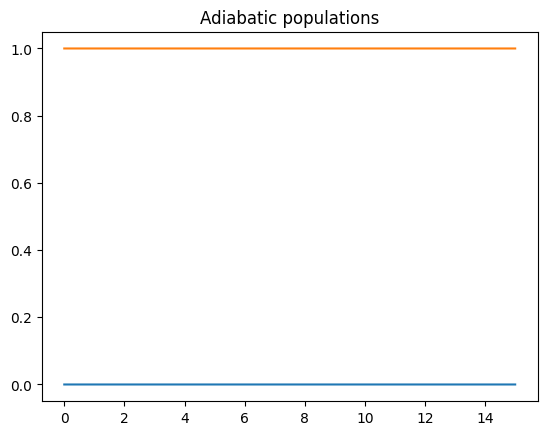

/Users/akrotz/Research/qclab-dev/.venv/lib/python3.9/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/akrotz/Research/qclab-dev/.venv/lib/python3.9/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


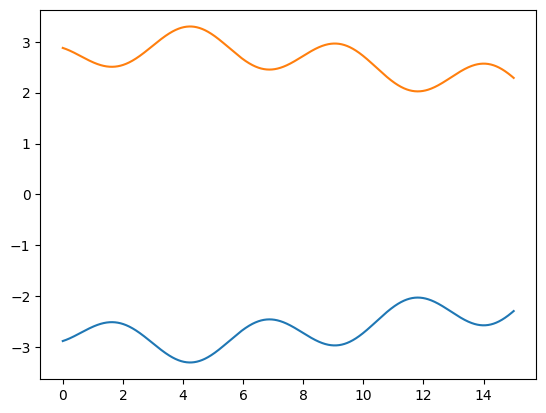

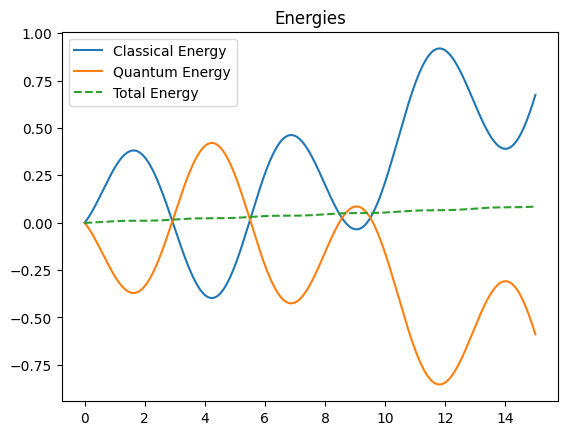

In [2]:

t = data.data_dict['t']
ec = data.data_dict['classical_energy']
eq = data.data_dict['quantum_energy']
pops_adb = np.real(np.einsum('tii->ti', data.data_dict['dm_db']))
energy = data.data_dict['energy']
plt.plot(t, pops_adb)
plt.title('Adiabatic populations')
plt.show()
plt.plot(t, energy)
plt.show()
etot = ec + eq
plt.plot(t, ec-ec[0], label='Classical Energy')
plt.plot(t, eq-eq[0], label='Quantum Energy')
plt.plot(t, etot-etot[0], label='Total Energy', linestyle='--')
plt.legend()
plt.title('Energies')
plt.show()

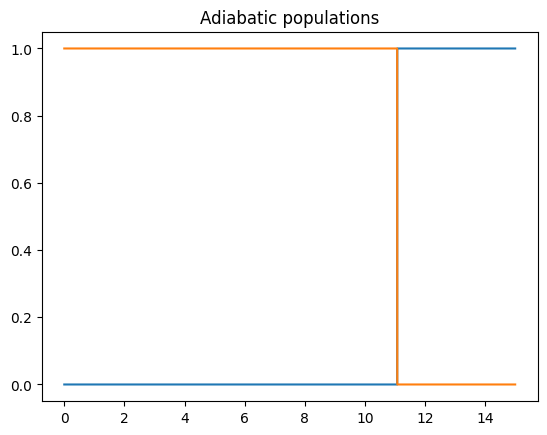

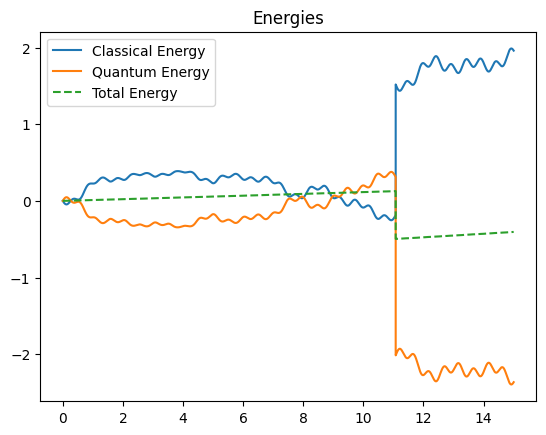

In [2]:

t = data.data_dict['t']
ec = data.data_dict['classical_energy']
eq = data.data_dict['quantum_energy']
pops_adb = np.real(np.einsum('tii->ti', data.data_dict['dm_db']))
plt.plot(t, pops_adb)
plt.title('Adiabatic populations')
plt.show()

etot = ec + eq
plt.plot(t, ec-ec[0], label='Classical Energy')
plt.plot(t, eq-eq[0], label='Quantum Energy')
plt.plot(t, etot-etot[0], label='Total Energy', linestyle='--')
plt.legend()
plt.title('Energies')
plt.show()

In [ ]:

t = data.data_dict['t']
ec = data.data_dict['classical_energy']
eq = data.data_dict['quantum_energy']
etot = ec + eq
plt.plot(t, ec-ec[0], label='Classical Energy')
plt.plot(t, eq-eq[0], label='Quantum Energy')
plt.plot(t, etot-etot[0], label='Total Energy', linestyle='--')
plt.legend()
plt.title('Energies')
plt.show()

In [ ]:

t = data.data_dict['t']
ec = data.data_dict['classical_energy']
eq = data.data_dict['quantum_energy']
etot = ec + eq
plt.plot(t, ec-ec[0], label='Classical Energy')
plt.plot(t, eq-eq[0], label='Quantum Energy')
plt.plot(t, etot-etot[0], label='Total Energy', linestyle='--')
plt.legend()
plt.title('Energies')
plt.show()